In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [ ]:
def segment(df, time_gap):
    """
    Segments a DataFrame by time and counts messages in segments meeting a minimum length.

    Args:
        df (pd.DataFrame): DataFrame with a "Time_Offset" column.
        time_gap (float): The duration of each time segment.

    Returns:
        list: A list of integers for message counts in segments with 240 or more messages.
    """
    # Ensure data is sorted by time for correct processing
    df_sorted = df.sort_values(by="Time_Offset").reset_index(drop=True)
    
    chunk_lengths = []
    # Get the start and end times of the entire dataset
    current_time = df_sorted['Time_Offset'].iloc[0]
    last_time = df_sorted['Time_Offset'].iloc[-1]

    # Loop as long as our time window is within the dataset's range
    while current_time <= last_time:
        # 1. Define the end of the current window
        window_end = current_time + time_gap
        
        # 2. Filter the DataFrame to get all data within this specific window
        segment_df = df_sorted[
            (df_sorted['Time_Offset'] >= current_time) & 
            (df_sorted['Time_Offset'] < window_end)
        ]
        
        # 3. NEW: Check the segment length BEFORE appending
        segment_len = len(segment_df)
        if segment_len >= 220:  # Condition: not less than 240
            chunk_lengths.append(segment_len)
        
        # 4. Crucially, move the window forward for the next iteration
        current_time = window_end

    return chunk_lengths

In [45]:
Forester_AF = pd.read_csv("Forester_AF.csv")
Gen_AF = pd.read_csv("Gen_AF.csv")
Gen_Korea_AF = pd.read_csv("Gen_Korea_AF.csv")
Kia_AF = pd.read_csv("Kia_AF.csv")
Kia_Korea_AF = pd.read_csv("Kia_Korea_AF.csv")
Sil_AF = pd.read_csv("Sil_AF.csv")
Sonata_Korea_AF = pd.read_csv("Sonata_Korea_AF.csv")
Tesla_AF = pd.read_csv("Tesla_AF.csv")

/tmp/ipykernel_11120/1267999064.py:2: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  Gen_AF = pd.read_csv("Gen_AF.csv")
/tmp/ipykernel_11120/1267999064.py:3: DtypeWarning: Columns (29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  Gen_Korea_AF = pd.read_csv("Gen_Korea_AF.csv")


In [46]:
Forester_AF

,Time_Offset,CAN_ID,Data_Length,One,Two,Three,Four,Five,Six,Seven,Eight,Label
0,0.000000,06CF,8,00,29,00,00,00,00,00,00,Normal
1,1.457930,0075,8,00,00,00,00,00,04,0E,81,Normal
2,1.671076,00D0,8,79,FE,00,00,00,00,FF,FF,Normal
3,1.848936,00D1,4,00,00,03,80,-1,-1,-1,-1,Normal
4,2.079964,0070,8,00,80,00,FF,EE,7F,0E,BB,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...
599995,371852.010965,0156,8,01,80,00,00,00,00,00,10,Normal
599996,371852.894068,0164,8,04,00,00,00,00,00,00,04,Normal
599997,371853.240967,0140,8,1B,09,71,06,00,1B,20,A0,Normal
599998,371853.465080,0141,8,99,29,42,2A,71,06,00,02,Normal


In [47]:
Forester_AF = segment(Forester_AF, 160)
Kia_AF = segment(Kia_AF, 100)
Kia_Korea_AF = segment(Kia_Korea_AF, 125)
Sil_AF = segment(Sil_AF, 100)
Sonata_Korea_AF = segment(Sonata_Korea_AF, 130)
Gen_AF = segment(Gen_AF, 105)
Gen_Korea_AF = segment(Gen_Korea_AF, 105)
Tesla_AF = segment(Tesla_AF, 83)

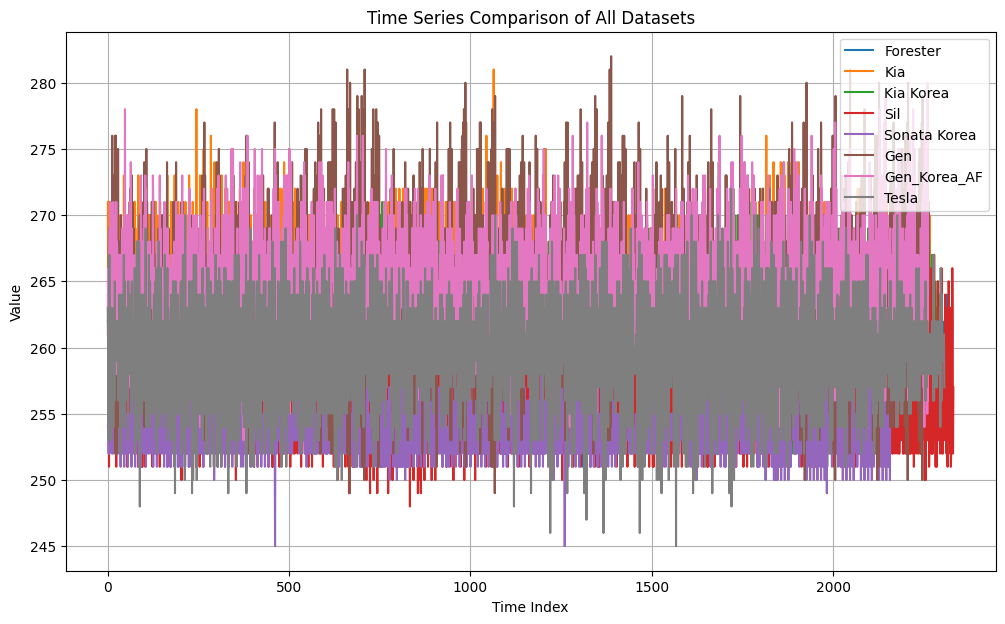

In [48]:
# It's good practice to set a figure size for better readability
plt.figure(figsize=(12, 7))

# Define the length to which all datasets will be sliced
# Your code attempted to slice up to the second-to-last element of Forester_AF

# Plot each dataset with a specific label for the legend
plt.plot(Forester_AF, label='Forester')
plt.plot(Kia_AF, label='Kia')
plt.plot(Kia_Korea_AF, label='Kia Korea')
plt.plot(Sil_AF, label='Sil')
plt.plot(Sonata_Korea_AF, label='Sonata Korea')
plt.plot(Gen_AF, label='Gen')
plt.plot(Gen_Korea_AF, label='Gen_Korea_AF')
plt.plot(Tesla_AF, label='Tesla')

# Add labels and a title to make the plot informative
plt.title('Time Series Comparison of All Datasets')
plt.xlabel('Time Index')
plt.ylabel('Value')

# Display the legend
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

In [38]:
pd.value_counts(Forester_AF)

/tmp/ipykernel_11120/984962029.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(Forester_AF)
/tmp/ipykernel_11120/984962029.py:1: FutureWarning: value_counts with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  pd.value_counts(Forester_AF)


262    600000
Name: count, dtype: int64

/tmp/ipykernel_11120/683790836.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(data_to_plot, labels=labels, patch_artist=True)
/tmp/ipykernel_11120/683790836.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', len(labels))


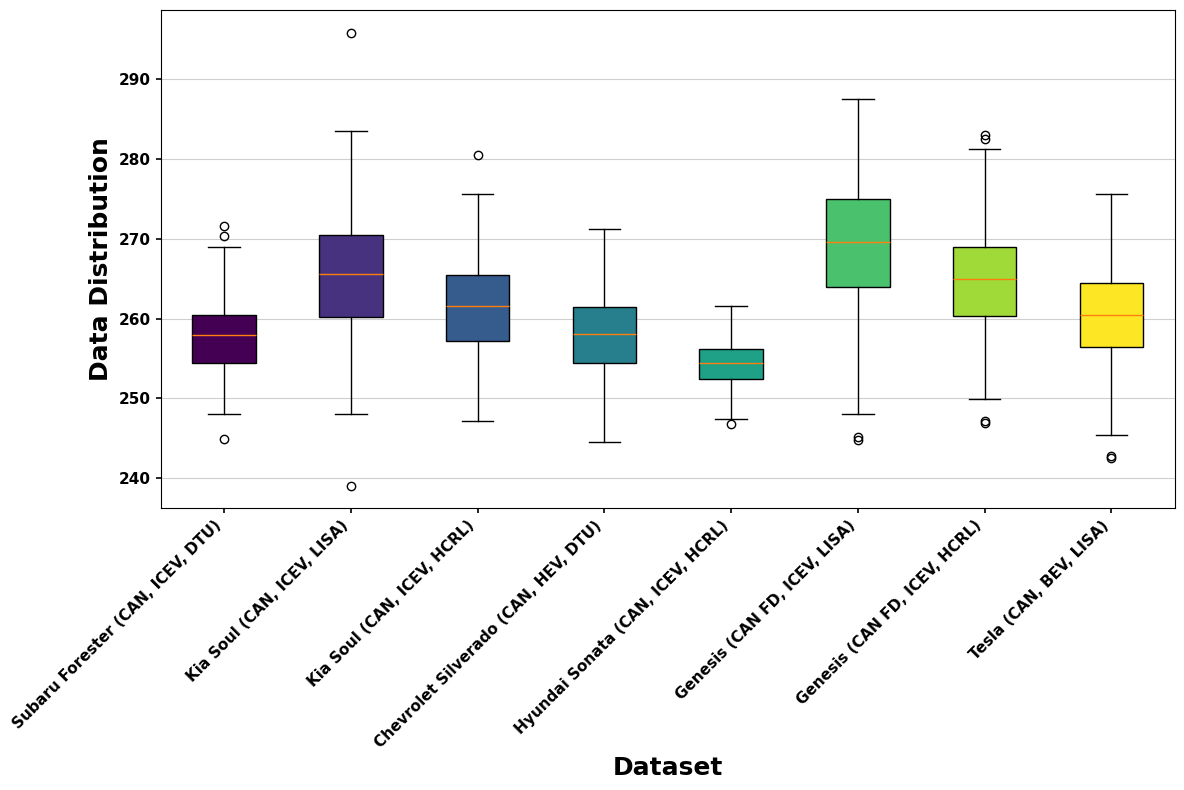

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# --- MOCK DATA ---
np.random.seed(42)
Forester_AF = np.random.normal(258, 5, 200)
Kia_AF = np.random.normal(265, 8, 200)
Kia_Korea_AF = np.random.normal(262, 6, 200)
Sil_AF = np.random.normal(258, 5, 200)
Sonata_Korea_AF = np.random.normal(254, 3, 200)
Gen_AF = np.random.normal(268, 8, 200)
Gen_Korea_AF = np.random.normal(265, 7, 200)
Tesla_AF = np.random.normal(260, 6, 200)

# --- DATASET LIST ---
data_to_plot = [
    Forester_AF, Kia_AF, Kia_Korea_AF, Sil_AF,
    Sonata_Korea_AF, Gen_AF, Gen_Korea_AF, Tesla_AF
]

labels = [
    'Subaru Forester (CAN, ICEV, DTU)', 
    'Kia Soul (CAN, ICEV, LISA)', 
    'Kia Soul (CAN, ICEV, HCRL)', 
    'Chevrolet Silverado (CAN, HEV, DTU)', 
    'Hyundai Sonata (CAN, ICEV, HCRL)', 
    'Genesis (CAN FD, ICEV, LISA)', 
    'Genesis (CAN FD, ICEV, HCRL)', 
    'Tesla (CAN, BEV, LISA)'
]

# --- FIGURE SETUP ---
plt.figure(figsize=(12, 8))
bplot = plt.boxplot(data_to_plot, labels=labels, patch_artist=True)

plt.xlabel('Dataset', fontsize=18, fontweight='bold')
plt.ylabel('Data Distribution', fontsize=18, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')

plt.tick_params(axis='both', which='both', width=1.2)  # make tick marks thicker
plt.grid(True, axis='y', linestyle='-', alpha=0.6)

# --- COLOR STYLING ---
cmap = plt.cm.get_cmap('viridis', len(labels))
colors = cmap(np.linspace(0, 1, len(labels)))
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')

plt.tight_layout()
plt.show()